# Simple Linear Regression

In [ ]:
import pandas as pd
from sklearn.datasets import load_wine

data = load_wine()
df = pd.DataFrame(data['data'], columns=data['feature_names'])
target = data['target']

feature = df["alcohol"]

178

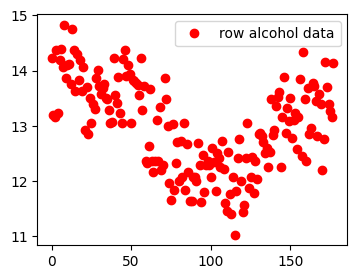

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize = (4,3))
plt.plot(feature, 'ro', label='row alcohol data')
plt.legend()
plt.show()

MSE: 0.507269587602501
R^2: 0.13039499268142662


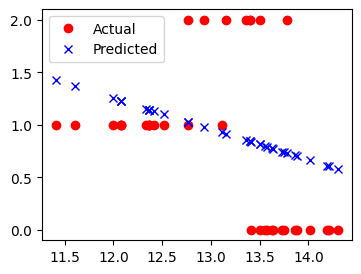

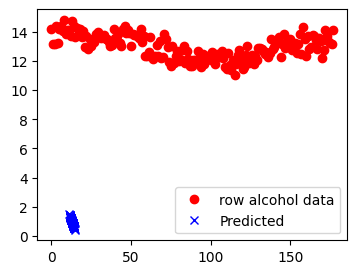

In [15]:
x = feature.values.reshape(-1, 1) # reshape the feature to be a 2D array so from [178, 89] to [[178], [89]]
y = target                        # the wine class labels

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# random_state is set to 42 to ensure that the split is reproducible. You can choose any integer value for random_state, and it will produce the same split of the data each time you run the code. This is useful for debugging and comparing results across different runs.

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

from sklearn.metrics import mean_squared_error, r2_score
print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))

plt.figure(figsize = (4,3))
plt.plot(x_test, y_test, 'ro', label='Actual')
plt.plot(x_test, y_pred, 'bx', label='Predicted')
plt.legend()
plt.show()

plt.figure(figsize = (4,3))
plt.plot(feature, 'ro', label='row alcohol data')
plt.plot(feature, model.predict(feature.values.reshape(-1, 1)), 'bx', label='Predicted')
plt.legend()
plt.show()

# Liniar regresion with two features

From the heatmap we can see that there is a corelation between proline and alcohol. This two will be the features for the model.

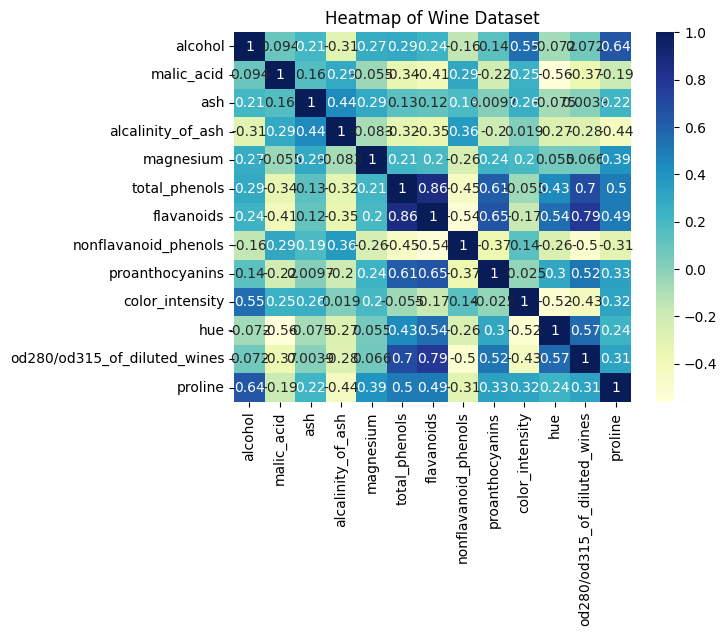

In [21]:
import seaborn as sb

dataplot = sb.heatmap(df.corr(), cmap="YlGnBu", annot=True)
plt.title('Heatmap of Wine Dataset')
plt.show()

Min fo: 278.0, Max fo: 1680.0
Min ft: 11.03, Max ft: 14.83


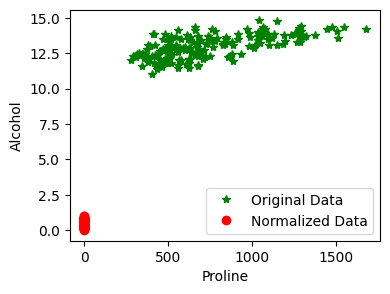

In [34]:
feature_one = df["proline"]
feature_two = df["alcohol"]

print(f'Min fo: {min(feature_one)}, Max fo: {max(feature_one)}')
print(f'Min ft: {min(feature_two)}, Max ft: {max(feature_two)}')

def min_max_normalization(feature):
    min_value = min(feature)
    max_value = max(feature)
    normalized_feature = (feature - min_value) / (max_value - min_value)
    return normalized_feature

normalized_feature_one = min_max_normalization(feature_one)
normalized_feature_two = min_max_normalization(feature_two)

plt.figure(figsize = (4,3))
plt.plot(feature_one, feature_two, 'g*', label='Original Data')
plt.plot(normalized_feature_one, normalized_feature_two, 'ro', label='Normalized Data')
plt.xlabel('Proline')
plt.ylabel('Alcohol')
plt.legend()
plt.show()

MSE: 0.3184458296600022
R^2: 0.4540928634399961


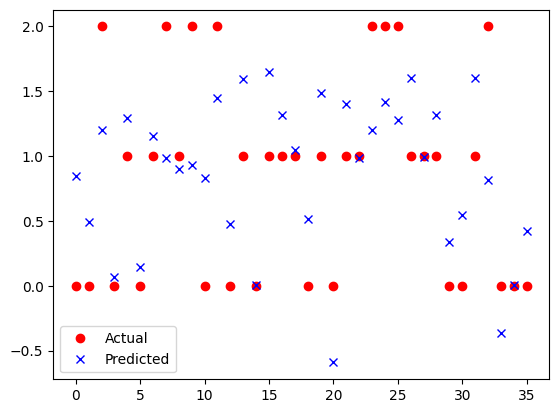

In [45]:
x = df[["proline", "alcohol"]].values
y = target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))

plt.plot(y_test, 'ro', label='Actual')
plt.plot(y_pred, 'bx', label='Predicted')
plt.legend()
plt.show()